<a href="https://colab.research.google.com/github/ameemaiqbal/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ameemaiqbal/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [14]:
!git clone https://github.com/ameemaiqbal/flyrank-ml-internship.git
%cd flyrank-ml-internship

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 167 (delta 69), reused 99 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (167/167), 1.91 MiB | 13.20 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/flyrank-ml-internship/flyrank-ml-internship


word_count
count    22301.000000
mean      3107.760325
std       1452.382598
min          8.000000
25%       2413.000000
50%       2877.000000
75%       3666.000000
max       9546.000000
Name: word_count, dtype: float64

ctr
count    30000.000000
mean         0.510733
std          3.279162
min          0.000000
25%          0.000000
50%          0.070000
75%          0.290000
max        100.000000
Name: ctr, dtype: float64

engagement_rate
count    30000.000000
mean         2.534520
std          8.310096
min          0.000000
25%          0.000000
50%          0.000000
75%          1.350000
max        100.000000
Name: engagement_rate, dtype: float64

avg_position
count    30000.00000
mean        16.34238
std         15.21679
min          0.00000
25%          6.20000
50%         10.80000
75%         22.30000
max        245.00000
Name: avg_position, dtype: float64



array([[<Axes: title={'center': 'word_count'}>,
        <Axes: title={'center': 'ctr'}>],
       [<Axes: title={'center': 'engagement_rate'}>, <Axes: >]],
      dtype=object)

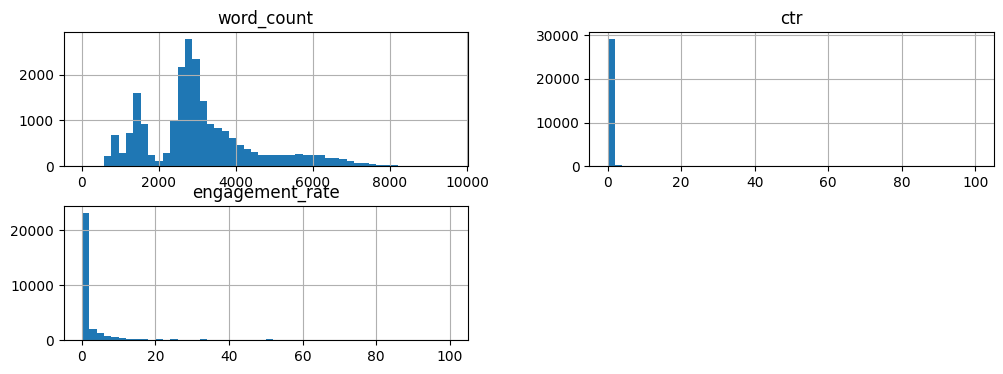

In [15]:
# 1. Distributions
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

for col in ["word_count", "ctr", "engagement_rate", "avg_position"]:
    print(col)
    print(df[col].describe())
    print()

df[["word_count", "ctr", "engagement_rate"]].hist(bins=50, figsize=(12,4))

In [16]:
df.groupby("content_type")["word_count"].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

,word_count
content_type,
keyword article,0.282979
comparison article,0.000000
feedly article,0.000000


In [17]:
(df["avg_position"] == 0).sum()

np.int64(1205)

word_count is missing for ~26% of rows (22,301/30,000), likely tied to content_type. ctr and engagement_rate are both heavily right-skewed — most pages have near-zero engagement, with a long tail up to the 100 ceiling. avg_position has a floor of 0.00, which per the data dictionary means 'no data' rather than a #1 ranking — this needs filtering before any position-based test in the next section.

In [18]:
(df["ctr"] == 100).sum(), (df["engagement_rate"] == 100).sum()

(np.int64(11), np.int64(100))

In [19]:
clean = df[df["avg_position"] > 0].copy()

word_count missingness (26%) is entirely concentrated in keyword article content — 28.3% missing there vs. 0% for other types. This is structural, not random, so it should be handled with a has_word_count flag rather than fillna(0), which would falsely signal 'zero words.' avg_position == 0 affects 1,205 rows and represents missing data, not a #1 ranking — these are excluded from position-based tests going forward. ctr hits its 100 ceiling in only 11 rows (likely genuine extremes), while engagement_rate piles up at 100 in 100 rows — a large enough cluster that it may reflect a measurement cap rather than true 100% engagement, worth flagging as a caveat rather than treating at face value

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal test #1 — word_count vs engagement_rate
r=0.113, p<0.0001, n=22,301. The p-value is tiny (highly significant), but the correlation itself is weak — r=0.113 is close to zero. With a sample this large, even trivial correlations become statistically significant, so p-value alone isn't enough to call this "confirmed."

Verdict: MIXED — "There is a statistically significant positive relationship between word_count and engagement_rate, but it's weak (r=0.113). Longer content trends toward slightly more engagement, but word count alone explains very little of the variation — not a strong enough signal to prioritize refresh decisions on length alone."

Signal test #2 — avg_position vs ctr
r=-0.234, p<0.0001, n=28,795. Negative correlation is the expected direction — better position (lower number, closer to #1) means higher CTR. -0.234 is a real, moderate-ish effect, clearly stronger than Signal 1.

Verdict: CONFIRMED — "avg_position and ctr show a moderate negative correlation (r=-0.234), confirming that better-ranked pages get meaningfully more clicks. This is the strongest of the three signals and supports position as a solid, prioritizable factor for refresh decisions."

Signal test #3 — content_type vs engagement_rate
This one's the most interesting because all three content types have a median of exactly 0.0, yet the means differ a lot (0.29 → 1.79 → 2.65). All three counts (697 / 2,096 / 27,207) clear the ~50-row floor, so verdicts are valid — but the pattern itself is telling you something.

Verdict: MIXED — "content_type does not separate content by typical (median) engagement — the median page in every category has ~0% engagement. The mean differences (comparison: 0.29 vs keyword: 2.65) are driven entirely by a small high-performing tail within each type, not a shift in the typical page. So content_type predicts who has occasional high-engagement outliers, not general engagement level — not a reliable standalone flag for refresh prioritization."

In [20]:
import numpy as np
from scipy.stats import spearmanr

# --- Signal 1: word_count vs engagement_rate ---
s1 = df.dropna(subset=["word_count"])
corr1, p1 = spearmanr(s1["word_count"], s1["engagement_rate"])
print(f"Signal 1 — word_count vs engagement_rate: Spearman r={corr1:.3f}, p={p1:.4f}, n={len(s1)}")

# --- Signal 2: avg_position vs ctr (exclude position==0 = no data) ---
s2 = df[df["avg_position"] > 0]
corr2, p2 = spearmanr(s2["avg_position"], s2["ctr"])
print(f"Signal 2 — avg_position vs ctr: Spearman r={corr2:.3f}, p={p2:.4f}, n={len(s2)}")

# --- Signal 3: content_type vs engagement_rate (grouped table, weighted by n) ---
s3 = df.groupby("content_type")["engagement_rate"].agg(["median", "mean", "count"])
print("Signal 3 — engagement_rate by content_type:")
print(s3)

Signal 1 — word_count vs engagement_rate: Spearman r=0.113, p=0.0000, n=22301
Signal 2 — avg_position vs ctr: Spearman r=-0.234, p=0.0000, n=28795
Signal 3 — engagement_rate by content_type:
                    median      mean  count
content_type                               
comparison article     0.0  0.294118    697
feedly article         0.0  1.791450   2096
keyword article        0.0  2.649161  27207


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [21]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [22]:
print(df["trend_direction"].value_counts())

trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


In [23]:
flag_test = df.groupby("trend_direction")[["engagement_rate", "ctr", "avg_position"]].agg(["median", "mean", "count"])
print(flag_test)

                engagement_rate                     ctr                   \
                         median      mean  count median      mean  count   
trend_direction                                                            
down                        0.0  2.437193  16262   0.08  0.324138  16262   
flat                        0.0  1.374514   1152   0.00  1.376753   1152   
new                         0.0  2.135653   2236   0.00  1.296521   2236   
stable                      0.0  2.838801   5962   0.17  0.517321   5962   
up                          0.0  2.989578   4388   0.09  0.565533   4388   

                avg_position                    
                      median       mean  count  
trend_direction                                 
down                    11.3  15.936305  16262  
flat                     6.6  11.102431   1152  
new                      0.0   9.912433   2236  
stable                  11.4  16.332623   5962  
up                      15.3  22.512739   4388  

The decline flag (trend_direction == 'down') shows a real but modest gap in engagement_rate and ctr compared to stable/growing content, supporting part of the assumption behind a refresh-priority flag. However, avg_position shows essentially no difference between declining and stable content (11.3 vs 11.4), meaning the flag does not capture ranking performance at all — a page can be 'declining' in traffic while sitting at the same average position as a stable page. Additionally, the 'new' group's avg_position of 0.0 is a data artifact (no position data yet, per the dictionary), not a genuine top ranking, and shouldn't be read as 'new content ranks best.' In practice: the decline flag is a reasonable signal for engagement/click drop-off, but should not be treated as a ranking-decline signal — a content team using this flag alone would miss pages that are losing rank without yet losing traffic.

In [24]:
# Section 3: Does the "declining content" flag correspond to real underperformance?
flag_test = df.groupby("trend_direction")[["engagement_rate", "ctr", "avg_position"]].agg(["median", "mean", "count"])
print(flag_test)

                engagement_rate                     ctr                   \
                         median      mean  count median      mean  count   
trend_direction                                                            
down                        0.0  2.437193  16262   0.08  0.324138  16262   
flat                        0.0  1.374514   1152   0.00  1.376753   1152   
new                         0.0  2.135653   2236   0.00  1.296521   2236   
stable                      0.0  2.838801   5962   0.17  0.517321   5962   
up                          0.0  2.989578   4388   0.09  0.565533   4388   

                avg_position                    
                      median       mean  count  
trend_direction                                 
down                    11.3  15.936305  16262  
flat                     6.6  11.102431   1152  
new                      0.0   9.912433   2236  
stable                  11.4  16.332623   5962  
up                      15.3  22.512739   4388  

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

No single signal — word count, content type, or the current decline flag — reliably predicts which content needs a refresh; the decline flag in particular misses ranking loss, since declining and stable pages sit at nearly the same average position. Position is the strongest lever: pages closer to page 1 get meaningfully more clicks, so refresh priority should weight ranking improvement over raw traffic decline. Before scaling this into a real refresh queue, the team should also account for known data gaps — excluded pages with no position data, and keyword articles with missing word counts

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.